In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from itertools import combinations
from tqdm import tqdm

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from nnfabrik.utility.nn_helpers import set_random_seed

In [ ]:
features_dict = {}


starting_epcoch = 1
multiplier = 1e5
exponent=2.0
clusters=15
alpha=2.1
pretrain_epoch = 10
lr_model=0.008
regularizer ='adlognorm'
seeds = [42,10,100]

# Iterate over models and extract features
for seed in seeds:
    features_combined = []
    print(seed)
    path_ending = f'without_KL_seed_{seed}_regularizer_l1'
    path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_{regularizer}_pe{pretrain_epoch}_lr_{lr_model}_64_seed_{seed}'
    save_path = f'../model_checkpoints/sensorium_model_dec_{path_ending}.pth'
    weights = torch.load(save_path, map_location='cpu')
    features_list = []
    for key, tensor in weights.items():
        if key.endswith('._features') and key.startswith('readout.'):
            features = tensor.detach().squeeze().T.cpu().numpy()
            features_list.append(features)
    features = np.vstack(features_list)
    features_dict[seed] = features

# Combine features across all readouts for each seed
combined_features_by_seed = {
    seed: np.vstack(features_list)
    for seed, features_list in features_dict.items()
}

# Print shapes
for seed, features in combined_features_by_seed.items():
    print(f"Shape for seed {seed}: {features.shape}")

42
10
100
Shape for seed 42: (54569, 64)
Shape for seed 10: (54569, 64)
Shape for seed 100: (54569, 64)


In [3]:
# Define seeds and number of clusters
seeds = [42, 10, 100]  # Example seed values
clusters_num = range(5,20)

# Dictionary to store cluster assignments
clusters = {}

# Apply KMeans clustering on the extracted features for each seed
for s in seeds:
    clusters[s] = {}  # Initialize dictionary for each seed
    features = features_dict[s]  # Get the corresponding features

    for c in clusters_num:
        kmeans = KMeans(n_clusters=c, random_state=42, n_init=10)
        clusters[s][c] = kmeans.fit_predict(features)

# Compute Adjusted Rand Index (ARI) between different seeds for each cluster count
adjusted_rand_adap = {}

for n_clust in tqdm(clusters[42].keys()):  # Iterate over cluster numbers
    adjusted_rand_adap[n_clust] = []

    for seed1, seed2 in combinations(seeds, 2):
        ari_score = adjusted_rand_score(clusters[seed1][n_clust], clusters[seed2][n_clust])
        adjusted_rand_adap[n_clust].append(ari_score)
    print(f"Clusters: {n_clust}, ARI Scores: {adjusted_rand_adap[n_clust]}")
# Print ARI results
#for n_clust, scores in adjusted_rand_adap.items():
#    print(f"Clusters: {n_clust}, ARI Scores: {scores}")

KeyboardInterrupt: 

In [4]:
import pickle
file_path = 'Polly_data/ARI_baseline_l1.pkl'

# Save the data into a .pkl file
#with open(file_path, 'wb') as f:
#    pickle.dump(adjusted_rand_adap, f)

with open(file_path, 'rb') as f:
    adjusted_rand_adap = pickle.load(f)
#print(f"Data saved to {file_path}")


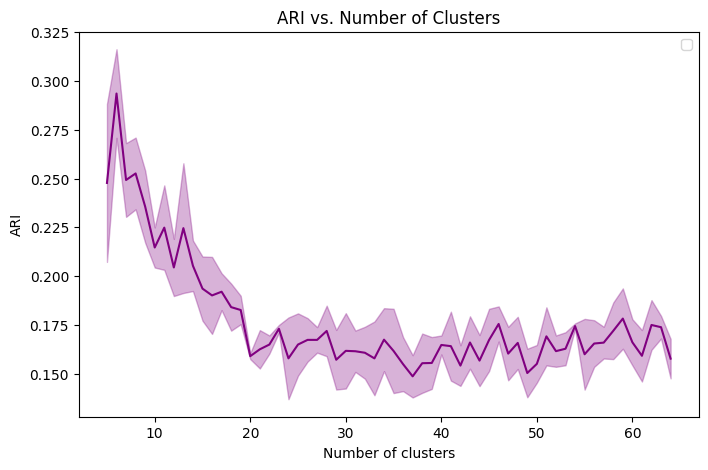

In [5]:
clusters_num = range(5,65)
ari_means = np.array([np.mean(adjusted_rand_adap[c]) for c in clusters_num])
ari_stds = np.array([np.std(adjusted_rand_adap[c]) for c in clusters_num])

# Plot
plt.figure(figsize=(8, 5))
plt.plot(clusters_num, ari_means, color="purple")
plt.fill_between(clusters_num, ari_means - ari_stds, ari_means + ari_stds, color="purple", alpha=0.3)

# Labels & Legend
plt.xlabel("Number of clusters")
plt.ylabel("ARI")
plt.legend()
plt.title("ARI vs. Number of Clusters")
plt.show()